# Random GST Minibatches with True Expectations

This notebook tests the experiment Matt suggested:

1. Use the same two-qubit pyGSTi model as `GST_model.ipynb`.
2. Use exact probabilities from the data-generation model, not finite-shot samples.
3. Randomly select batches of GST circuits.
4. Optimize only on the selected batch.
5. Evaluate the optimized model on the full GST circuit set.
6. Repeat many times to get empirical distributions of full-objective values.

The central question is:

$$\text{If a random subset of circuits fits well, does it also predict the circuits that were not used?}$$

If yes, then random minibatches may be informative enough to motivate a future minibatch/adaptive-circuit POUNDERS method.

## 1. Imports and Configuration

The default is a small smoke test so the notebook does not accidentally launch hundreds of expensive GST fits. To run Matt's proposed experiment, set `RUN_FULL_STUDY = True`.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

import pygsti
from pygsti.modelpacks import smq2Q_XYICNOT
from pygsti.protocols import StandardGSTDesign

np.set_printoptions(precision=8, suppress=True)

In [2]:
# Same model/design settings as GST_model.ipynb.
MAX_LENGTHS = [1, 2, 4, 8, 16]
OP_NOISE = 0.01
SPAM_NOISE = 0.005
DATA_SEED = 100

# Study controls.
RUN_FULL_STUDY = True

# Matt's suggested full-study settings.
FULL_NUM_REPEATS = 100
FULL_BATCH_MULTIPLIERS = [0.5, 1, 2, 4]

# Safer settings for checking that the notebook works.
SMOKE_NUM_REPEATS = FULL_NUM_REPEATS
SMOKE_BATCH_MULTIPLIERS = FULL_BATCH_MULTIPLIERS

# Optimization controls. Increase MAX_NFEV for more accurate solutions.
# method='trf' is usually more stable for large dense Jacobians than method='lm'.
SCIPY_METHOD = "trf"
MAX_NFEV = 25
XTOL = 1e-8
FTOL = 1e-8
GTOL = 1e-8

# Randomness only controls which circuits are selected. There is no shot noise here.
RNG_SEED = 20260611

OUTPUT_DIR = Path("minibatch_true_expectation_results")
OUTPUT_DIR.mkdir(exist_ok=True)

num_repeats = FULL_NUM_REPEATS if RUN_FULL_STUDY else SMOKE_NUM_REPEATS
batch_multipliers = FULL_BATCH_MULTIPLIERS if RUN_FULL_STUDY else SMOKE_BATCH_MULTIPLIERS

print("RUN_FULL_STUDY:", RUN_FULL_STUDY)
print("num_repeats:", num_repeats)
print("batch_multipliers:", batch_multipliers)
print("optimizer:", SCIPY_METHOD)
print("MAX_NFEV:", MAX_NFEV)

RUN_FULL_STUDY: True
num_repeats: 100
batch_multipliers: [0.5, 1, 2, 4]
optimizer: trf
MAX_NFEV: 25


## 2. Build the Same pyGSTi Model and Circuit Pool

In [3]:
def model_num_params(model):
    value = model.num_params
    return value() if callable(value) else int(value)


target_model = smq2Q_XYICNOT.target_model()
modelpack = smq2Q_XYICNOT
processor_spec = modelpack.processor_spec()

prep_fiducials = modelpack.prep_fiducials()
meas_fiducials = modelpack.meas_fiducials()
germs = modelpack.germs()

gst_design = StandardGSTDesign(
    processor_spec,
    prep_fiducials,
    meas_fiducials,
    germs,
    MAX_LENGTHS,
)

all_circuits = list(gst_design.all_circuits_needing_data)

data_generation_model = target_model.depolarize(
    op_noise=OP_NOISE,
    spam_noise=SPAM_NOISE,
    seed=DATA_SEED,
)

x0 = np.asarray(target_model.to_vector(), dtype=float)
x_star = np.asarray(data_generation_model.to_vector(), dtype=float)
p = int(x0.size)

print("number of parameters p:", p)
print("number of GST circuits:", len(all_circuits))
print("nominal probability entries:", 4 * len(all_circuits))
print("||x_star - x0||_2:", float(np.linalg.norm(x_star - x0)))
print("operation labels:", [str(label) for label in target_model.operations.keys()])

number of parameters p: 1616
number of GST circuits: 8740
nominal probability entries: 34960
||x_star - x0||_2: 0.09496709956611298
operation labels: ['[]', 'Gxpi2:1', 'Gypi2:1', 'Gxpi2:0', 'Gypi2:0', 'Gcnot:0:1']


## 3. Exact Probability Oracle

This is the true-expectation version. There are no shots and no multinomial sampling.

For a circuit batch $B$, the training residual is

$$r_B(x) = p_B(x) - p_B(x^*).$$

After fitting on $B$, we evaluate the same $x$ on all circuits.

In [4]:
def exact_probabilities_and_labels(model, circuits, labels=None):
    probs_by_circuit = model.bulk_probabilities(circuits)
    values = []
    out_labels = []

    if labels is None:
        for circuit in circuits:
            probs = probs_by_circuit[circuit]
            for outcome in probs.keys():
                values.append(float(probs[outcome]))
                out_labels.append((circuit, outcome))
    else:
        for circuit, outcome in labels:
            probs = probs_by_circuit[circuit]
            values.append(float(probs.get(outcome, 0.0)))
            out_labels.append((circuit, outcome))

    return np.asarray(values, dtype=float), out_labels


def model_from_vector(template_model, x):
    model = template_model.copy()
    model.from_vector(np.asarray(x, dtype=float), close=False)
    return model


def make_exact_reference(circuits):
    f_exact, labels = exact_probabilities_and_labels(data_generation_model, circuits)
    return f_exact, labels


def probability_vector_from_x(x, circuits, labels):
    model = model_from_vector(target_model, x)
    p_values, _ = exact_probabilities_and_labels(model, circuits, labels=labels)
    return p_values


full_f_exact, full_labels = make_exact_reference(all_circuits)

p_at_xstar = probability_vector_from_x(x_star, all_circuits, full_labels)
zero_check_residual = p_at_xstar - full_f_exact

print("full exact probability vector shape:", full_f_exact.shape)
print("full objective at x0:", float(np.sum((probability_vector_from_x(x0, all_circuits, full_labels) - full_f_exact) ** 2)))
print("full objective at x_star:", float(np.sum(zero_check_residual ** 2)))
print("max abs residual at x_star:", float(np.max(np.abs(zero_check_residual))))

full exact probability vector shape: (34960,)
full objective at x0: 25.713774476742476
full objective at x_star: 0.0
max abs residual at x_star: 0.0


## 4. Residual and Jacobian for a Circuit Batch

The optimizer sees only the selected batch. The full circuit set is used only for evaluation after the batch fit.

In [5]:
def residual_and_jacobian_for_batch(x, batch_circuits, batch_f_exact, batch_labels):
    model = model_from_vector(target_model, x)
    probs_by_circuit = model.bulk_probabilities(batch_circuits)
    dprobs_by_circuit = model.sim.bulk_dprobs(batch_circuits)

    residual_values = []
    jacobian_rows = []

    for value_index, (circuit, outcome) in enumerate(batch_labels):
        probs = probs_by_circuit[circuit]
        dprobs = dprobs_by_circuit[circuit]
        residual_values.append(float(probs.get(outcome, 0.0)) - batch_f_exact[value_index])
        jacobian_rows.append(np.asarray(dprobs[outcome], dtype=float))

    return np.asarray(residual_values, dtype=float), np.vstack(jacobian_rows)


def fit_on_circuit_batch(batch_circuits, x_initial):
    batch_f_exact, batch_labels = make_exact_reference(batch_circuits)

    eval_count = {"n": 0}
    cache = {"x": None, "residual": None, "jacobian": None}

    def evaluate(x):
        x = np.asarray(x, dtype=float)
        if cache["x"] is not None and np.array_equal(x, cache["x"]):
            return cache["residual"], cache["jacobian"]

        eval_count["n"] += 1
        residual, jacobian = residual_and_jacobian_for_batch(
            x,
            batch_circuits,
            batch_f_exact,
            batch_labels,
        )
        cache["x"] = x.copy()
        cache["residual"] = residual
        cache["jacobian"] = jacobian
        return residual, jacobian

    def fun(x):
        residual, _ = evaluate(x)
        return residual

    def jac(x):
        _, jacobian = evaluate(x)
        return jacobian

    start_time = time.perf_counter()
    result = least_squares(
        fun,
        x_initial,
        jac=jac,
        method=SCIPY_METHOD,
        max_nfev=MAX_NFEV,
        xtol=XTOL,
        ftol=FTOL,
        gtol=GTOL,
        verbose=0,
    )
    elapsed = time.perf_counter() - start_time

    train_residual = result.fun
    return {
        "x_hat": np.asarray(result.x, dtype=float),
        "success": bool(result.success),
        "status": int(result.status),
        "message": str(result.message),
        "nfev": int(result.nfev),
        "njev": int(result.njev) if result.njev is not None else np.nan,
        "oracle_calls": int(eval_count["n"]),
        "elapsed_seconds": float(elapsed),
        "train_num_probability_entries": int(train_residual.size),
        "train_objective": float(np.sum(train_residual ** 2)),
        "train_rmse": float(np.sqrt(np.mean(train_residual ** 2))),
        "train_max_abs_residual": float(np.max(np.abs(train_residual))),
    }


def evaluate_on_full_set(x_hat):
    p_hat_full = probability_vector_from_x(x_hat, all_circuits, full_labels)
    residual = p_hat_full - full_f_exact
    return {
        "full_objective": float(np.sum(residual ** 2)),
        "full_rmse": float(np.sqrt(np.mean(residual ** 2))),
        "full_max_abs_residual": float(np.max(np.abs(residual))),
    }

## 5. Run the Random Minibatch Study

Here `p` is the number of model parameters, 1616 for this model. This notebook treats Matt's sample sizes `{p, 2p, 4p, ...}` as **numbers of circuits**. Since each two-qubit circuit has four outcomes with one normalization constraint, this is a conservative choice: it gives more probability equations than parameters.

Each trial samples a new random circuit batch, fits only that batch, and records the full-set objective.

In [6]:
rng = np.random.default_rng(RNG_SEED)

batch_sizes = []
for multiplier in batch_multipliers:
    size = int(multiplier * p)
    if size <= len(all_circuits):
        batch_sizes.append(size)
    else:
        print(f"Skipping {multiplier}p = {size} circuits because only {len(all_circuits)} circuits exist.")

print("batch sizes in circuits:", batch_sizes)
print("repeats per batch size:", num_repeats)

batch sizes in circuits: [808, 1616, 3232, 6464]
repeats per batch size: 100


In [7]:
rows = []

for batch_size in batch_sizes:
    for repeat_index in range(num_repeats):
        selected_indices = rng.choice(len(all_circuits), size=batch_size, replace=False)
        batch_circuits = [all_circuits[int(i)] for i in selected_indices]

        print(f"batch_size={batch_size}, repeat={repeat_index + 1}/{num_repeats}")
        fit_result = fit_on_circuit_batch(batch_circuits, x_initial=x0)
        full_eval = evaluate_on_full_set(fit_result["x_hat"])

        row = {
            "batch_size_circuits": int(batch_size),
            "batch_size_over_p": float(batch_size / p),
            "repeat": int(repeat_index),
            "num_parameters": int(p),
            "full_num_circuits": int(len(all_circuits)),
            "full_num_probability_entries": int(full_f_exact.size),
            "optimizer": SCIPY_METHOD,
            "max_nfev": int(MAX_NFEV),
            "success": fit_result["success"],
            "status": fit_result["status"],
            "message": fit_result["message"],
            "nfev": fit_result["nfev"],
            "njev": fit_result["njev"],
            "oracle_calls": fit_result["oracle_calls"],
            "elapsed_seconds": fit_result["elapsed_seconds"],
            "train_num_probability_entries": fit_result["train_num_probability_entries"],
            "train_objective": fit_result["train_objective"],
            "train_rmse": fit_result["train_rmse"],
            "train_max_abs_residual": fit_result["train_max_abs_residual"],
            "full_objective": full_eval["full_objective"],
            "full_rmse": full_eval["full_rmse"],
            "full_max_abs_residual": full_eval["full_max_abs_residual"],
            "x_distance_to_true_l2_gauge_dependent": float(np.linalg.norm(fit_result["x_hat"] - x_star)),
        }
        rows.append(row)

        partial_results = pd.DataFrame(rows)
        partial_results.to_csv(OUTPUT_DIR / "random_minibatch_true_expectation_partial.csv", index=False)
        print("  train objective:", row["train_objective"])
        print("  full objective :", row["full_objective"])
        print("  elapsed seconds:", row["elapsed_seconds"])

results_df = pd.DataFrame(rows)
results_path = OUTPUT_DIR / "random_minibatch_true_expectation_results.csv"
results_df.to_csv(results_path, index=False)

print("saved:", results_path)
results_df

batch_size=808, repeat=1/100
  train objective: 1.506079887425417e-19
  full objective : 4.028517971596829
  elapsed seconds: 78.15403948900348
batch_size=808, repeat=2/100
  train objective: 1.4625851558533856e-10
  full objective : 2.3424948905642733
  elapsed seconds: 78.28011560099549
batch_size=808, repeat=3/100
  train objective: 2.4452777033861777e-15
  full objective : 13.55972076015037
  elapsed seconds: 78.76626853099151
batch_size=808, repeat=4/100
  train objective: 2.5413250215252e-27
  full objective : 6.868960132082833
  elapsed seconds: 60.816798378000385
batch_size=808, repeat=5/100
  train objective: 1.824318554263629e-18
  full objective : 10.56412485819794
  elapsed seconds: 75.80832248501247
batch_size=808, repeat=6/100
  train objective: 3.5540128915283633e-26
  full objective : 4.420435039585906
  elapsed seconds: 65.80663893399469
batch_size=808, repeat=7/100
  train objective: 1.1385556747278074e-12
  full objective : 6.024397501792543
  elapsed seconds: 74.284

,batch_size_circuits,batch_size_over_p,repeat,num_parameters,full_num_circuits,full_num_probability_entries,optimizer,max_nfev,success,status,...,oracle_calls,elapsed_seconds,train_num_probability_entries,train_objective,train_rmse,train_max_abs_residual,full_objective,full_rmse,full_max_abs_residual,x_distance_to_true_l2_gauge_dependent
0,808,0.5,0,1616,8740,34960,trf,25,True,1,...,24,78.154039,3232,1.506080e-19,6.826346e-12,1.393030e-10,4.028518e+00,1.073463e-02,3.643519e-01,0.655316
1,808,0.5,1,1616,8740,34960,trf,25,False,0,...,25,78.280116,3232,1.462585e-10,2.127281e-07,2.219317e-06,2.342495e+00,8.185658e-03,4.110520e-01,0.620754
2,808,0.5,2,1616,8740,34960,trf,25,False,0,...,25,78.766269,3232,2.445278e-15,8.698181e-10,2.400964e-08,1.355972e+01,1.969426e-02,5.737339e-01,0.942851
3,808,0.5,3,1616,8740,34960,trf,25,True,1,...,20,60.816798,3232,2.541325e-27,8.867362e-16,2.381428e-14,6.868960e+00,1.401715e-02,5.359754e-01,0.682326
4,808,0.5,4,1616,8740,34960,trf,25,True,1,...,25,75.808322,3232,1.824319e-18,2.375826e-11,3.791785e-10,1.056412e+01,1.738325e-02,4.809671e-01,0.742823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,6464,4.0,95,1616,8740,34960,trf,25,True,1,...,18,311.858080,25856,1.969747e-27,2.760098e-16,1.387779e-15,2.647832e-27,2.752070e-16,1.387779e-15,0.875667
396,6464,4.0,96,1616,8740,34960,trf,25,True,1,...,18,322.836743,25856,1.012308e-27,1.978680e-16,1.332268e-15,1.363446e-27,1.974846e-16,1.332268e-15,0.878305
397,6464,4.0,97,1616,8740,34960,trf,25,True,1,...,18,320.076733,25856,3.745412e-27,3.806003e-16,1.637579e-15,5.120015e-27,3.826925e-16,1.637579e-15,0.876515
398,6464,4.0,98,1616,8740,34960,trf,25,True,1,...,18,317.078191,25856,2.610325e-27,3.177362e-16,1.443290e-15,2.289161e+01,2.558895e-02,2.022444e+00,1.072390


## 6. Summarize Empirical Distributions

In [8]:
if len(results_df) == 0:
    print("No results yet. Run the study cell first.")
else:
    summary = (
        results_df
        .groupby("batch_size_circuits")
        .agg(
            repeats=("full_objective", "count"),
            median_full_objective=("full_objective", "median"),
            mean_full_objective=("full_objective", "mean"),
            min_full_objective=("full_objective", "min"),
            max_full_objective=("full_objective", "max"),
            median_full_rmse=("full_rmse", "median"),
            median_elapsed_seconds=("elapsed_seconds", "median"),
            success_rate=("success", "mean"),
        )
        .reset_index()
    )
    summary_path = OUTPUT_DIR / "random_minibatch_true_expectation_summary.csv"
    summary.to_csv(summary_path, index=False)
    print("saved:", summary_path)
    display(summary)

saved: minibatch_true_expectation_results/random_minibatch_true_expectation_summary.csv


,batch_size_circuits,repeats,median_full_objective,mean_full_objective,min_full_objective,max_full_objective,median_full_rmse,median_elapsed_seconds,success_rate
0,808,100,5.699996e+00,11.084411,1.296097e+00,92.199167,1.276801e-02,72.672669,0.29
1,1616,100,1.678061e+00,7.337328,9.437628e-02,89.845632,6.926955e-03,131.286532,0.41
2,3232,100,1.152815e+00,76.781913,8.022909e-09,5432.630093,5.740258e-03,183.453478,0.96
3,6464,100,2.338191e-27,0.359514,1.307805e-27,22.891608,2.585986e-16,339.014318,1.00


## 7. Plot Full-Set Objective Distributions

These plots are the main output: they show whether random circuit batches generalize to the full GST circuit set.

/tmp/ipykernel_1089/1909897726.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data, labels=labels, showfliers=True)


saved: minibatch_true_expectation_results/random_minibatch_true_expectation_boxplot.png


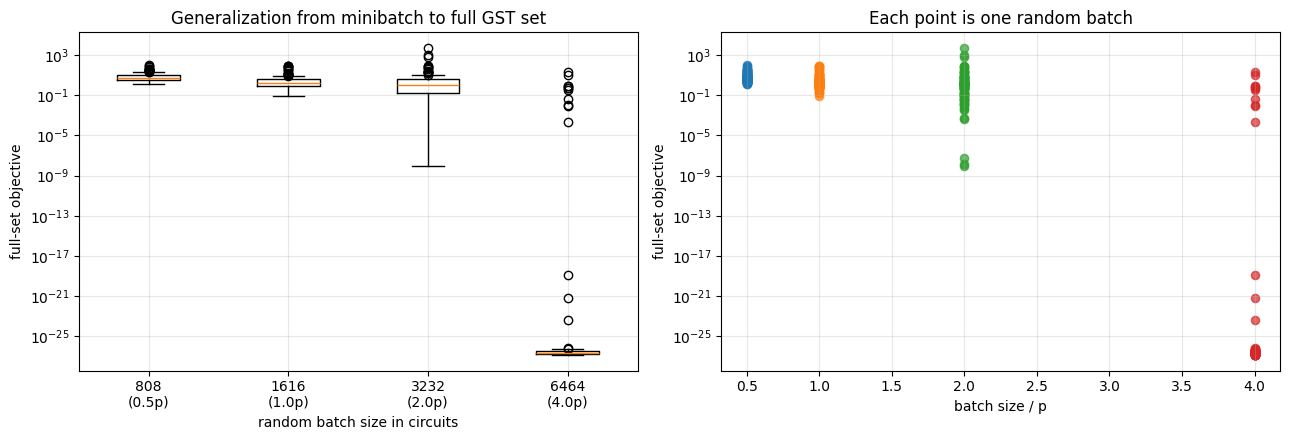

In [9]:
if len(results_df) == 0:
    print("No results yet. Run the study cell first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    labels = []
    data = []
    for batch_size, group in results_df.groupby("batch_size_circuits"):
        labels.append(f"{batch_size}\n({batch_size / p:.1f}p)")
        data.append(group["full_objective"].to_numpy(dtype=float))

    axes[0].boxplot(data, labels=labels, showfliers=True)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("random batch size in circuits")
    axes[0].set_ylabel("full-set objective")
    axes[0].set_title("Generalization from minibatch to full GST set")
    axes[0].grid(True, alpha=0.3)

    for batch_size, group in results_df.groupby("batch_size_circuits"):
        axes[1].scatter(
            np.full(len(group), batch_size / p),
            group["full_objective"],
            alpha=0.7,
            s=35,
            label=f"{batch_size} circuits",
        )
    axes[1].set_yscale("log")
    axes[1].set_xlabel("batch size / p")
    axes[1].set_ylabel("full-set objective")
    axes[1].set_title("Each point is one random batch")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    figure_path = OUTPUT_DIR / "random_minibatch_true_expectation_boxplot.png"
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")
    print("saved:", figure_path)

## 8. Interpretation Guide

For each random circuit batch, compare:

- `train_objective`: how well the fitted model matches the selected circuits.
- `full_objective`: how well that same fitted model matches all GST circuits.

Possible outcomes:

1. `train_objective` small and `full_objective` small: the random batch generalized well.
2. `train_objective` small but `full_objective` large: the batch was not informative enough; it fit the selected circuits but failed on holdout circuits.
3. Both large: the optimizer did not solve the batch problem well, or the batch problem is ill-conditioned.

If the empirical distribution of `full_objective` becomes small for batch sizes like `p`, `2p`, or `4p`, then minibatch GST may be promising. If not, random circuit batches are probably too weak and adaptive circuit selection would need a smarter scoring rule.